# Time Series Data Analysis - Whole Stock Market Dataset

This notebook completes Task 10 for the Data Analytics Internship using the whole dataset in the `DATA` folder. It loads all stock and ETF CSV files, combines them into one dataset, creates an aggregate market time series, checks stationarity, calculates moving averages, identifies trend/seasonality, and creates a forecasting plot.

## 1. Import Libraries

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

## 2. Load The Whole Dataset

The dataset contains thousands of stock and ETF CSV files. To keep memory usage reasonable, the notebook loads only the columns needed for time-series analysis.

In [2]:
BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = BASE_DIR / "DATA"
OUTPUT_DIR = BASE_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

csv_files = list((DATA_DIR / "stocks").glob("*.csv")) + list((DATA_DIR / "etfs").glob("*.csv"))
print("Total CSV files:", len(csv_files))

frames = []
for csv_path in csv_files:
    asset_type = csv_path.parent.name
    symbol = csv_path.stem
    temp = pd.read_csv(csv_path, usecols=["Date", "Adj Close", "Volume"], parse_dates=["Date"])
    temp["Symbol"] = symbol
    temp["Asset_Type"] = asset_type
    frames.append(temp)

all_data = pd.concat(frames, ignore_index=True)
all_data = all_data.dropna(subset=["Date", "Adj Close"])
all_data = all_data.sort_values(["Symbol", "Date"])
all_data.head()

Total CSV files: 8049


,Date,Adj Close,Volume,Symbol,Asset_Type
0,1999-11-18,27.068665,62546300.0,A,stocks
1,1999-11-19,24.838577,15234100.0,A,stocks
2,1999-11-22,27.068665,6577800.0,A,stocks
3,1999-11-23,24.607880,5975600.0,A,stocks
4,1999-11-24,25.261524,4843200.0,A,stocks


## 3. Dataset Overview

In [3]:
print("Rows:", len(all_data))
print("Symbols:", all_data["Symbol"].nunique())
print("Start date:", all_data["Date"].min().date())
print("End date:", all_data["Date"].max().date())
print("Asset types:")
print(all_data["Asset_Type"].value_counts())

all_data.groupby("Asset_Type")["Symbol"].nunique().to_frame("unique_symbols")

Rows: 28151075
Symbols: 8049
Start date: 1962-01-02
End date: 2020-04-01
Asset types:
Asset_Type
stocks    24196793
etfs       3954282
Name: count, dtype: int64


,unique_symbols
Asset_Type,
etfs,2165
stocks,5884


## 4. Create Aggregate Market Time Series

A single forecasting target is needed for time-series modeling. Here, the target is the daily average adjusted close across every available stock and ETF.

In [4]:
market_daily = (
    all_data.groupby("Date")
    .agg(
        avg_adj_close=("Adj Close", "mean"),
        total_volume=("Volume", "sum"),
        active_symbols=("Symbol", "nunique"),
    )
    .sort_index()
)
market_daily = market_daily.asfreq("B")
market_daily["avg_adj_close"] = market_daily["avg_adj_close"].ffill()
market_daily["total_volume"] = market_daily["total_volume"].fillna(0)
market_daily["active_symbols"] = market_daily["active_symbols"].ffill()
market_daily.head()

,avg_adj_close,total_volume,active_symbols
Date,,,
1962-01-02,6.248174,8981800.0,20.0
1962-01-03,6.331877,9100500.0,20.0
1962-01-04,6.260292,10589000.0,20.0
1962-01-05,6.314560,12193400.0,20.0
1962-01-08,6.222530,13473600.0,20.0


## 5. Visualize Whole Dataset Market Average

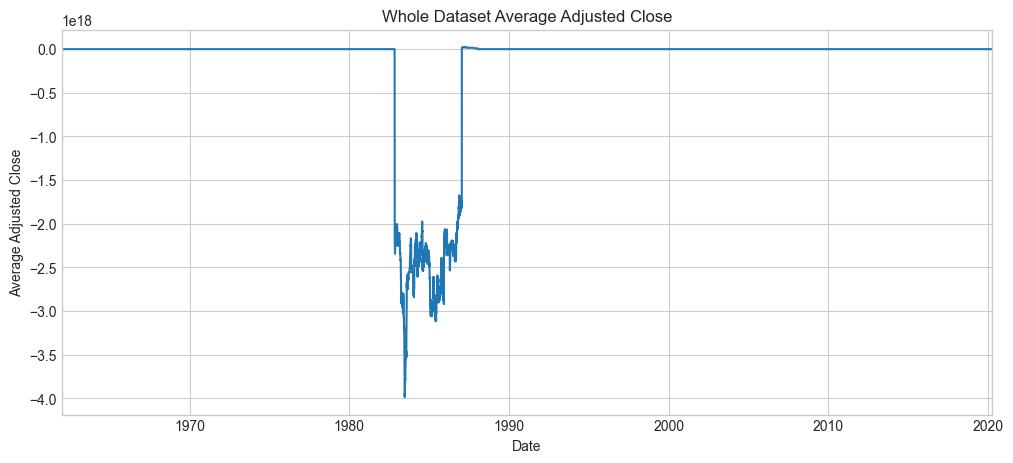

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
market_daily["avg_adj_close"].plot(ax=ax, color="#1f77b4")
ax.set_title("Whole Dataset Average Adjusted Close")
ax.set_xlabel("Date")
ax.set_ylabel("Average Adjusted Close")
plt.show()

## 6. Moving Averages

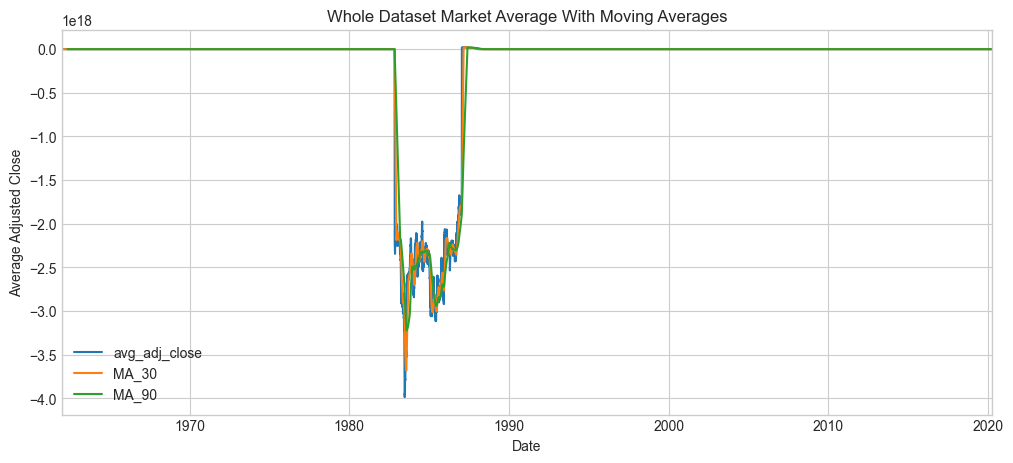

In [6]:
market_daily["MA_30"] = market_daily["avg_adj_close"].rolling(window=30).mean()
market_daily["MA_90"] = market_daily["avg_adj_close"].rolling(window=90).mean()

fig, ax = plt.subplots(figsize=(12, 5))
market_daily[["avg_adj_close", "MA_30", "MA_90"]].plot(ax=ax)
ax.set_title("Whole Dataset Market Average With Moving Averages")
ax.set_xlabel("Date")
ax.set_ylabel("Average Adjusted Close")
plt.show()

## 7. Stationarity Check

In [7]:
def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f"ADF Test for {name}")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"  {key}: {value:.4f}")
    if result[1] <= 0.05:
        print("Conclusion: Series is likely stationary.")
    else:
        print("Conclusion: Series is likely non-stationary.")

adf_test(market_daily["avg_adj_close"], "Whole Dataset Average Adjusted Close")

ADF Test for Whole Dataset Average Adjusted Close
ADF Statistic: -2.3415
p-value: 0.1589
Critical Values:
  1%: -3.4308
  5%: -2.8617
  10%: -2.5669
Conclusion: Series is likely non-stationary.


The raw market average usually contains trend, so we also test daily percentage change.

In [8]:
market_daily["daily_return"] = market_daily["avg_adj_close"].pct_change()
adf_test(market_daily["daily_return"], "Whole Dataset Daily Return")

ADF Test for Whole Dataset Daily Return
ADF Statistic: -123.2680
p-value: 0.0000
Critical Values:
  1%: -3.4308
  5%: -2.8617
  10%: -2.5669
Conclusion: Series is likely stationary.


## 8. Identify Trend and Seasonality

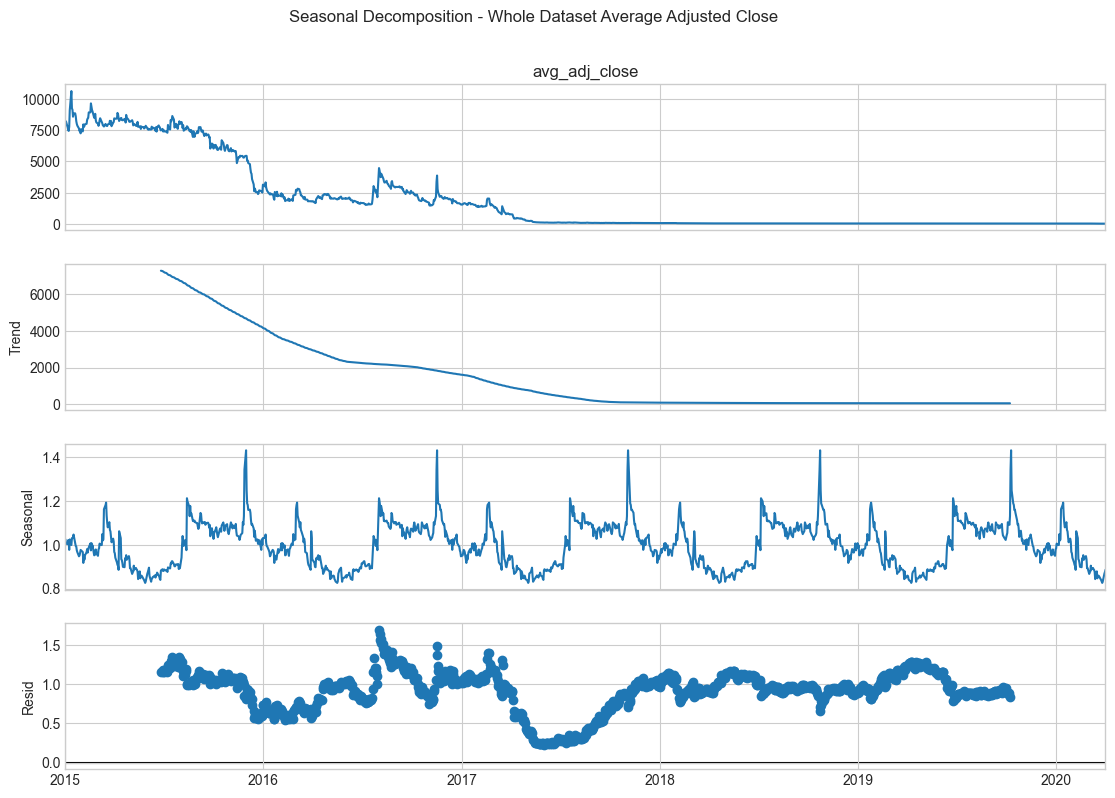

In [9]:
recent = market_daily["avg_adj_close"].loc["2015":].dropna()
decomposition = seasonal_decompose(recent, model="multiplicative", period=252)

fig = decomposition.plot()
fig.set_size_inches(12, 8)
fig.suptitle("Seasonal Decomposition - Whole Dataset Average Adjusted Close", y=1.02)
plt.show()

A period of 252 is used because there are roughly 252 trading days in a year.

## 9. Forecasting With SARIMAX

In [10]:
model_series = market_daily["avg_adj_close"].loc["2015":].dropna()
train = model_series.iloc[:-60]
test = model_series.iloc[-60:]

model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 5),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
results = model.fit(disp=False)

forecast = results.get_forecast(steps=len(test))
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

forecast_mean.head()

2020-01-09    41.813743
2020-01-10    38.778548
2020-01-13    34.489842
2020-01-14    29.652821
2020-01-15    20.748887
Freq: B, Name: predicted_mean, dtype: float64

## 10. Forecasting Plot

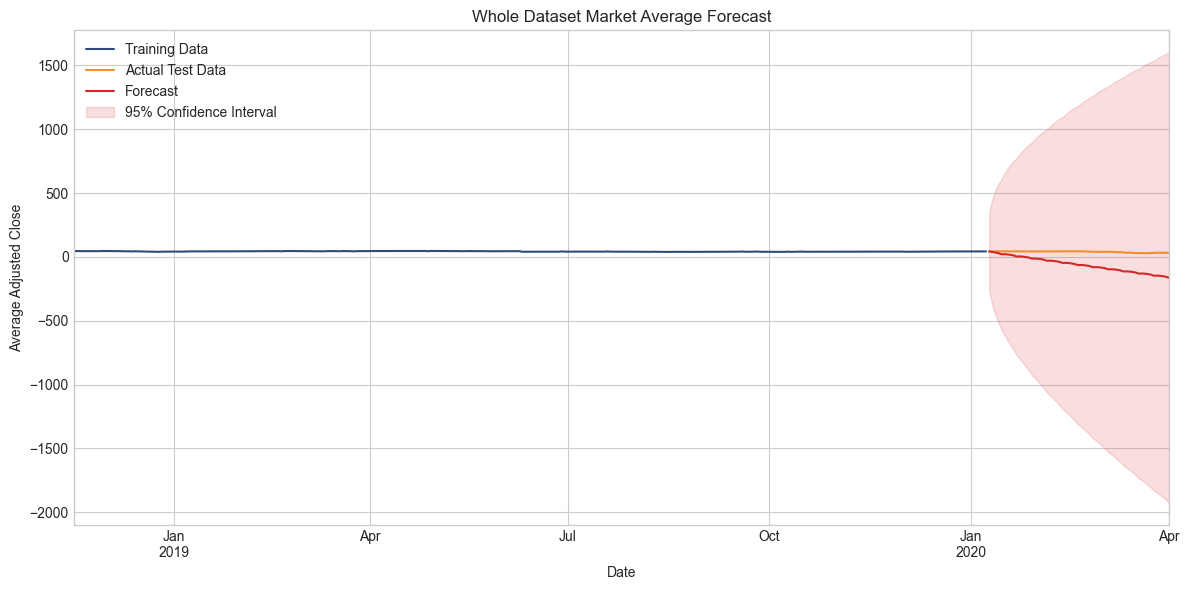

Forecasting plot saved to: c:\Users\HP\Desktop\data science\Time-Series-Data-Analysis\outputs\whole_dataset_forecast.png


In [11]:
fig, ax = plt.subplots(figsize=(12, 6))
train.iloc[-300:].plot(ax=ax, label="Training Data", color="#2f4b7c")
test.plot(ax=ax, label="Actual Test Data", color="#f28e2b")
forecast_mean.plot(ax=ax, label="Forecast", color="#d62728")
ax.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    color="#d62728",
    alpha=0.15,
    label="95% Confidence Interval",
)
ax.set_title("Whole Dataset Market Average Forecast")
ax.set_xlabel("Date")
ax.set_ylabel("Average Adjusted Close")
ax.legend()
plt.tight_layout()

plot_path = OUTPUT_DIR / "whole_dataset_forecast.png"
plt.savefig(plot_path, dpi=150)
plt.show()

print(f"Forecasting plot saved to: {plot_path}")

## 11. Symbol-Level Summary

In [12]:
symbol_summary = (
    all_data.groupby(["Asset_Type", "Symbol"])
    .agg(
        start_date=("Date", "min"),
        end_date=("Date", "max"),
        observations=("Date", "count"),
        mean_adj_close=("Adj Close", "mean"),
        last_adj_close=("Adj Close", "last"),
        mean_volume=("Volume", "mean"),
    )
    .sort_values("observations", ascending=False)
)
symbol_summary.head(20)

start_date   end_date  observations  mean_adj_close  \
Asset_Type Symbol                                                       
stocks     IP     1962-01-02 2020-04-01         14663       13.656553   
           IBM    1962-01-02 2020-04-01         14663       39.328815   
           ARNC   1962-01-02 2020-04-01         14663       18.326753   
           XOM    1962-01-02 2020-04-01         14663       19.763669   
           HPQ    1962-01-02 2020-04-01         14663        4.432726   
           ED     1962-01-02 2020-04-01         14663       15.619932   
           DTE    1962-01-02 2020-04-01         14663       18.090887   
           MO     1962-01-02 2020-04-01         14663        7.837306   
           CAT    1962-01-02 2020-04-01         14663       21.631381   
           AA     1962-01-02 2020-04-01         14663       20.456199   
           GE     1962-01-02 2020-04-01         14663        7.302201   
           GT     1962-01-02 2020-04-01         14663       13.263907   
           KO     1962-01-02 2020-04-01         14663        9.579523   
           JNJ    1962-01-02 2020-04-01         14663       24.020434   
           NAV    1962-01-02 2020-04-01         14663      102.854674   
           PG     1962-01-02 2020-04-01         14663       19.923234   
           BA     1962-01-02 2020-04-01         14663       37.759821   
           FL     1962-01-02 2020-04-01         14663       12.398006   
           DIS    1962-01-02 2020-04-01         14663       20.257553   
           CVX    1962-01-02 2020-04-01         14663       22.909865   

                   last_adj_close   mean_volume  
Asset_Type Symbol                                
stocks     IP           30.150000  1.721687e+06  
           IBM         105.139999  4.864190e+06  
           ARNC         13.200000  3.103903e+06  
           XOM          37.529999  8.495592e+06  
           HPQ          14.840000  1.479227e+07  
           ED           77.610001  7.461771e+05  
           DTE          88.080002  4.526116e+05  
           MO           37.610001  6.597705e+06  
           CAT         111.349998  3.090661e+06  
           AA            6.250000  2.617908e+06  
           GE            7.040000  2.335178e+07  
           GT            5.690000  1.521333e+06  
           KO           42.119999  8.826423e+06  
           JNJ         128.809998  5.484288e+06  
           NAV          16.030001  3.967562e+05  
           PG          109.330002  4.939900e+06  
           BA          130.699997  2.947188e+06  
           FL           20.150000  9.564541e+05  
           DIS          94.919998  6.022937e+06  
           CVX          68.559998  3.584978e+06

## 12. Conclusion

- The notebook uses the full dataset from both `DATA/stocks` and `DATA/etfs`.
- A combined table is created with Date, adjusted close, volume, symbol, and asset type.
- A whole-dataset market average series is used for time-series modeling.
- Moving averages reveal the smoothed trend.
- ADF testing checks stationarity for the raw series and daily returns.
- Seasonal decomposition separates trend, annual seasonality, and residual movement.
- SARIMAX creates the final forecasting plot for the aggregate market series.